Christakakis, P., Pechlivani, E.-M., & Dimou, P. (2025). Thermal PV Panel Detection and Fault Detection Dataset for UAV-Based Inspection [Data set]. Zenodo. https://doi.org/10.5281/zenodo.16420123
(CC-BY)

# YOLOv8 Validation
Download and prepare data

In [ ]:
# Replace with the actual Zenodo URL
!wget -O data.zip "https://zenodo.org/records/16420123/files/Thermal%20PV%20Panel%20Detection%20Dataset%20for%20UAV%20Inspection.zip?download=1"
!unzip data.zip

In [ ]:
import os

data_source_dir = '/content/data_source'

# List all files in the directory
all_files = os.listdir(data_source_dir)

# Separate image and text files
txt_files = {f for f in all_files if f.endswith('.txt')}
image_extensions = ['.jpg', '.jpeg', '.png']
image_files = {f for f in all_files if any(f.lower().endswith(ext) for ext in image_extensions)}

# Get the base names without extensions for comparison
txt_basenames = {os.path.splitext(f)[0] for f in txt_files}
image_basenames = {os.path.splitext(f)[0] for f in image_files}

# Find image basenames that do not have a corresponding text basename
extra_image_basenames = image_basenames - txt_basenames

# Find the full filenames of the extra image files
extra_image_files = [f for f in image_files if os.path.splitext(f)[0] in extra_image_basenames]

print("Image files without a corresponding .txt file:")
for extra_image in extra_image_files:
    print(extra_image)

Image files without a corresponding .txt file:
DJI_20230213170209_0001_T_JPG.rf.95b9dbd9c1b1989c443bc23d004cb355.jpg
DJI_20230213170213_0003_T_JPG.rf.18f02dbe2b7e0d7981d3578a9243d566.jpg


In [ ]:
import os
import shutil

data_source_dir = '/content/data_source'
destination_dir = '/content/'

for file_name in extra_image_files:
    source_file_path = os.path.join(data_source_dir, file_name)
    destination_file_path = os.path.join(destination_dir, file_name)
    try:
        shutil.move(source_file_path, destination_file_path)
        print(f"Moved {file_name} to {destination_dir}")
    except FileNotFoundError:
        print(f"Error: {file_name} not found in {data_source_dir}")
    except Exception as e:
        print(f"Error moving {file_name}: {e}")

Moved DJI_20230213170209_0001_T_JPG.rf.95b9dbd9c1b1989c443bc23d004cb355.jpg to /content/
Moved DJI_20230213170213_0003_T_JPG.rf.18f02dbe2b7e0d7981d3578a9243d566.jpg to /content/


# Apply the trained YOLOv8
Apply the trained YOLOv8 model on the validation images, save the predicted labels and output images with bounding boxes, measure the inference time for each image, and report the average inference time per image.

## Load the trained model

### Subtask:
Load the best-trained model weights.


**Reasoning**:
Load the best-trained model weights using the YOLO class from ultralytics.



In [ ]:
from ultralytics import YOLO

# Load the best-trained model weights
best_model_path = '/content/runs/detect/train2/weights/best.pt'
model = YOLO(best_model_path)

print(f"Loaded best-trained model from: {best_model_path}")

Loaded best-trained model from: /content/runs/detect/train2/weights/best.pt


## Define input and output paths

### Subtask:
Specify the directory containing the validation images and the directory where the output should be saved.


**Reasoning**:
Define the directories for validation images and output, and print them.



In [ ]:
import os

# Define the directory containing the validation images
yolov8_dataset_dir = '/content/yolov8_dataset'
val_image_dir = os.path.join(yolov8_dataset_dir, 'val', 'images')

# Define the directory where the output should be saved
output_dir = '/content/yolov8_inference_output'
os.makedirs(output_dir, exist_ok=True)

# Print the defined directories
print(f"Validation image directory: {val_image_dir}")
print(f"Output directory: {output_dir}")

Validation image directory: /content/yolov8_dataset/val/images
Output directory: /content/yolov8_inference_output


**Reasoning**:
Run inference on the validation images using the trained model, save the predicted labels and output images with bounding boxes, and measure the inference time for each image.



In [ ]:
import time
import glob

# Get a list of all image files in the validation directory
val_image_paths = glob.glob(os.path.join(val_image_dir, '*'))

inference_times = []

# Iterate through each validation image
for image_path in val_image_paths:
    # Measure inference time
    start_time = time.time()
    results = model(image_path, save=True, save_txt=True, project=output_dir, exist_ok=True, verbose=False)
    end_time = time.time()

    # Store the inference time
    inference_times.append(end_time - start_time)

print("Inference complete for all validation images.")

Results saved to /content/yolov8_inference_output/predict
1 label saved to /content/yolov8_inference_output/predict/labels
Results saved to /content/yolov8_inference_output/predict
2 labels saved to /content/yolov8_inference_output/predict/labels
Results saved to /content/yolov8_inference_output/predict
3 labels saved to /content/yolov8_inference_output/predict/labels
Results saved to /content/yolov8_inference_output/predict
4 labels saved to /content/yolov8_inference_output/predict/labels
Results saved to /content/yolov8_inference_output/predict
5 labels saved to /content/yolov8_inference_output/predict/labels
Results saved to /content/yolov8_inference_output/predict
6 labels saved to /content/yolov8_inference_output/predict/labels
Results saved to /content/yolov8_inference_output/predict
7 labels saved to /content/yolov8_inference_output/predict/labels
Results saved to /content/yolov8_inference_output/predict
8 labels saved to /content/yolov8_inference_output/predict/labels
Results s

**Reasoning**:
Calculate and print the average inference time per image.



In [ ]:
import numpy as np

# Calculate the average inference time
average_inference_time = np.mean(inference_times)

# Print the average inference time
print(f"Average inference time per image: {average_inference_time:.4f} seconds")

Average inference time per image: 0.0941 seconds


## Summary:

### Data Analysis Key Findings

*   The best-trained YOLOv8 model was successfully loaded from `/content/runs/detect/train2/weights/best.pt`.
*   Validation images were processed from `/content/yolov8_dataset/val/images`.
*   Predicted labels and output images with bounding boxes were saved to `/content/yolov8_inference_output/predict`.
*   The average inference time per image on the validation set was approximately 0.0941 seconds.

### Insights or Next Steps

*   The average inference time provides a baseline for the model's performance speed on this hardware. Consider optimizing the model or using hardware acceleration for faster inference if needed for real-time applications.
*   Review the saved output images and predicted labels in `/content/yolov8_inference_output/predict` to visually assess the model's performance and identify areas for potential improvement in training or data.


In [ ]:
!zip -r /content/train2_output.zip /content/runs/detect/train2

  adding: content/runs/detect/train2/ (stored 0%)
  adding: content/runs/detect/train2/results.png (deflated 9%)
  adding: content/runs/detect/train2/BoxF1_curve.png (deflated 18%)
  adding: content/runs/detect/train2/val_batch2_pred.jpg (deflated 4%)
  adding: content/runs/detect/train2/weights/ (stored 0%)
  adding: content/runs/detect/train2/weights/best.pt (deflated 10%)
  adding: content/runs/detect/train2/weights/last.pt (deflated 10%)
  adding: content/runs/detect/train2/labels.jpg (deflated 29%)
  adding: content/runs/detect/train2/confusion_matrix.png (deflated 36%)
  adding: content/runs/detect/train2/train_batch5390.jpg (deflated 5%)
  adding: content/runs/detect/train2/results.csv (deflated 67%)
  adding: content/runs/detect/train2/BoxP_curve.png (deflated 26%)
  adding: content/runs/detect/train2/BoxR_curve.png (deflated 18%)
  adding: content/runs/detect/train2/val_batch1_labels.jpg (deflated 3%)
  adding: content/runs/detect/train2/train_batch5391.jpg (deflated 5%)
  add

# Check detections
Compare the number of predicted objects to the number of objects in the validation labels for each image.

![train_batch5390.jpg](train_batch5390.jpg)

![train_batch5392.jpg](train_batch5392.jpg)

## Define label directories

### Subtask:
Specify the directories containing the predicted labels and the ground truth validation labels.


**Reasoning**:
Define the directories for predicted labels and ground truth labels and print them.



In [ ]:
import os

# Define the directory containing the predicted labels
predicted_labels_dir = '/content/yolov8_inference_output/predict/labels'

# Define the directory containing the ground truth validation labels
ground_truth_labels_dir = '/content/yolov8_dataset/val/labels'

# Print the paths of both directories
print(f"Predicted labels directory: {predicted_labels_dir}")
print(f"Ground truth labels directory: {ground_truth_labels_dir}")

Predicted labels directory: /content/yolov8_inference_output/predict/labels
Ground truth labels directory: /content/yolov8_dataset/val/labels


**Reasoning**:
Compare the number of predicted objects to the number of objects in the validation labels for each image and provide a summary.



In [ ]:
import glob

# Get list of predicted label files
predicted_label_files = glob.glob(os.path.join(predicted_labels_dir, '*.txt'))

# Get list of ground truth label files
ground_truth_label_files = glob.glob(os.path.join(ground_truth_labels_dir, '*.txt'))

# Create dictionaries to store object counts for each image
predicted_object_counts = {}
ground_truth_object_counts = {}

# Function to count objects in a label file
def count_objects_in_label_file(filepath):
    count = 0
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.strip():
                    count += 1
    except FileNotFoundError:
        count = 0 # Handle cases where a file might not exist
    return count

# Populate predicted object counts
for filepath in predicted_label_files:
    filename = os.path.basename(filepath)
    predicted_object_counts[filename] = count_objects_in_label_file(filepath)

# Populate ground truth object counts
for filepath in ground_truth_label_files:
    filename = os.path.basename(filepath)
    ground_truth_object_counts[filename] = count_objects_in_label_file(filepath)

# Compare counts and summarize
print("\nComparison of Predicted vs. Ground Truth Object Counts:")
for filename in ground_truth_object_counts:
    predicted_count = predicted_object_counts.get(filename, 0)
    ground_truth_count = ground_truth_object_counts[filename]
    print(f"  {filename}: Predicted = {predicted_count}, Ground Truth = {ground_truth_count}")

# Provide overall summary statistics
all_predicted_counts = list(predicted_object_counts.values())
all_ground_truth_counts = list(ground_truth_object_counts.values())

if all_ground_truth_counts:
    total_ground_truth_objects = sum(all_ground_truth_counts)
    total_predicted_objects = sum(all_predicted_counts)

    print("\nOverall Summary:")
    print(f"  Total Ground Truth Objects: {total_ground_truth_objects}")
    print(f"  Total Predicted Objects: {total_predicted_objects}")

    # Calculate average counts
    average_ground_truth = np.mean(all_ground_truth_counts) if all_ground_truth_counts else 0
    average_predicted = np.mean(all_predicted_counts) if all_predicted_counts else 0

    print(f"  Average Ground Truth Objects per Image: {average_ground_truth:.2f}")
    print(f"  Average Predicted Objects per Image: {average_predicted:.2f}")

else:
    print("\nNo ground truth label files found to compare.")



Comparison of Predicted vs. Ground Truth Object Counts:
  DJI_20230213160639_0152_T_JPG.rf.caf5a78dc86bf25c69aa78a5d0849e58.txt: Predicted = 87, Ground Truth = 84
  DJI_20230213155927_0030_T_JPG.rf.7f06dfac5c3883a89f92c4a3ddc0ab80.txt: Predicted = 34, Ground Truth = 33
  DJI_20230213160620_0147_T_JPG.rf.37ffe9b1db315b757a2773c2afe71023.txt: Predicted = 82, Ground Truth = 81
  DJI_20230213162046_0375_T_JPG.rf.8ff2eeb1ae30a63f646e42dfbb2d8a1f.txt: Predicted = 300, Ground Truth = 370
  DJI_20230213165141_0160_T_JPG.rf.1f7082325e63b6521337043421f5760b.txt: Predicted = 16, Ground Truth = 16
  DJI_20230213152949_0010_T_JPG.rf.e8aba6e1f6f2841b6505285bbb807d2a.txt: Predicted = 206, Ground Truth = 203
  DJI_20230213163948_0062_T_JPG.rf.e4c2636823de993eef03c321eb4edf4f.txt: Predicted = 26, Ground Truth = 26
  DJI_20230213162014_0364_T_JPG.rf.e1cdb73e36e800d90703d44311b9d2f0.txt: Predicted = 300, Ground Truth = 375
  DJI_20230213164727_0108_T_JPG.rf.c7b005811747eb0ed517739a0f174d21.txt: Predicte

## Summarize findings

### Subtask:
Summarize the comparison across all validation images.


**Reasoning**:
Summarize the comparison across all validation images based on the previously calculated total and average counts.



In [ ]:
# Summarize the comparison based on the printed output from the previous step

print("Summary of Comparison between Predicted and Ground Truth Object Counts:")

# Access the calculated total and average counts from the previous step
# Assuming the variables total_ground_truth_objects, total_predicted_objects,
# average_ground_truth, and average_predicted are available from the previous step.

print(f"\nTotal Ground Truth Objects across all validation images: {total_ground_truth_objects}")
print(f"Total Predicted Objects across all validation images: {total_predicted_objects}")

print(f"\nAverage Ground Truth Objects per Image: {average_ground_truth:.2f}")
print(f"Average Predicted Objects per Image: {average_predicted:.2f}")

# Analyze the general agreement or disagreement
difference_in_totals = total_ground_truth_objects - total_predicted_objects
difference_in_averages = average_ground_truth - average_predicted

print(f"\nDifference in total objects (Ground Truth - Predicted): {difference_in_totals}")
print(f"Difference in average objects per image (Ground Truth - Predicted): {difference_in_averages:.2f}")

if abs(difference_in_totals) < total_ground_truth_objects * 0.1: # Arbitrary threshold for 'general agreement'
    print("\nGeneral agreement: The total predicted object count is relatively close to the total ground truth object count.")
else:
    print("\nGeneral disagreement: There is a notable difference between the total predicted object count and the total ground truth object count.")


# Note any significant discrepancies based on the per-image comparison output from the previous step
# This part is based on observation of the previous output which showed some predicted counts capped at 300.
print("\nObservations on per-image discrepancies:")
print("  - In several images with high object counts, the predicted count appears to be capped at 300.")
print("  - This suggests that the model or the inference process might have a limit on the maximum number of detections per image.")
print("  - For images with lower object counts, the predicted counts generally align well with the ground truth counts.")

Summary of Comparison between Predicted and Ground Truth Object Counts:

Total Ground Truth Objects across all validation images: 7330
Total Predicted Objects across all validation images: 6928

Average Ground Truth Objects per Image: 97.73
Average Predicted Objects per Image: 92.37

Difference in total objects (Ground Truth - Predicted): 402
Difference in average objects per image (Ground Truth - Predicted): 5.36

General agreement: The total predicted object count is relatively close to the total ground truth object count.

Observations on per-image discrepancies:
  - In several images with high object counts, the predicted count appears to be capped at 300.
  - This suggests that the model or the inference process might have a limit on the maximum number of detections per image.
  - For images with lower object counts, the predicted counts generally align well with the ground truth counts.


## Summary:

### Data Analysis Key Findings

*   The total number of ground truth objects across all validation images is 7330, while the total number of predicted objects is 6928.
*   The average number of ground truth objects per image is 97.73, compared to an average of 92.37 predicted objects per image.
*   There is a difference of 402 fewer predicted objects in total compared to the ground truth, and an average difference of 5.36 fewer predicted objects per image.
*   A notable discrepancy was observed in images with high object counts, where the predicted count appeared to be capped at 300.

### Insights or Next Steps

*   Investigate the cause of the predicted object count being capped at 300 in images with high object density, as this limits the model's ability to detect all objects in crowded scenes.
*   Analyze the performance metrics (like precision, recall, and F1-score) specifically for images with high object counts to understand the impact of the prediction limit on overall model performance.


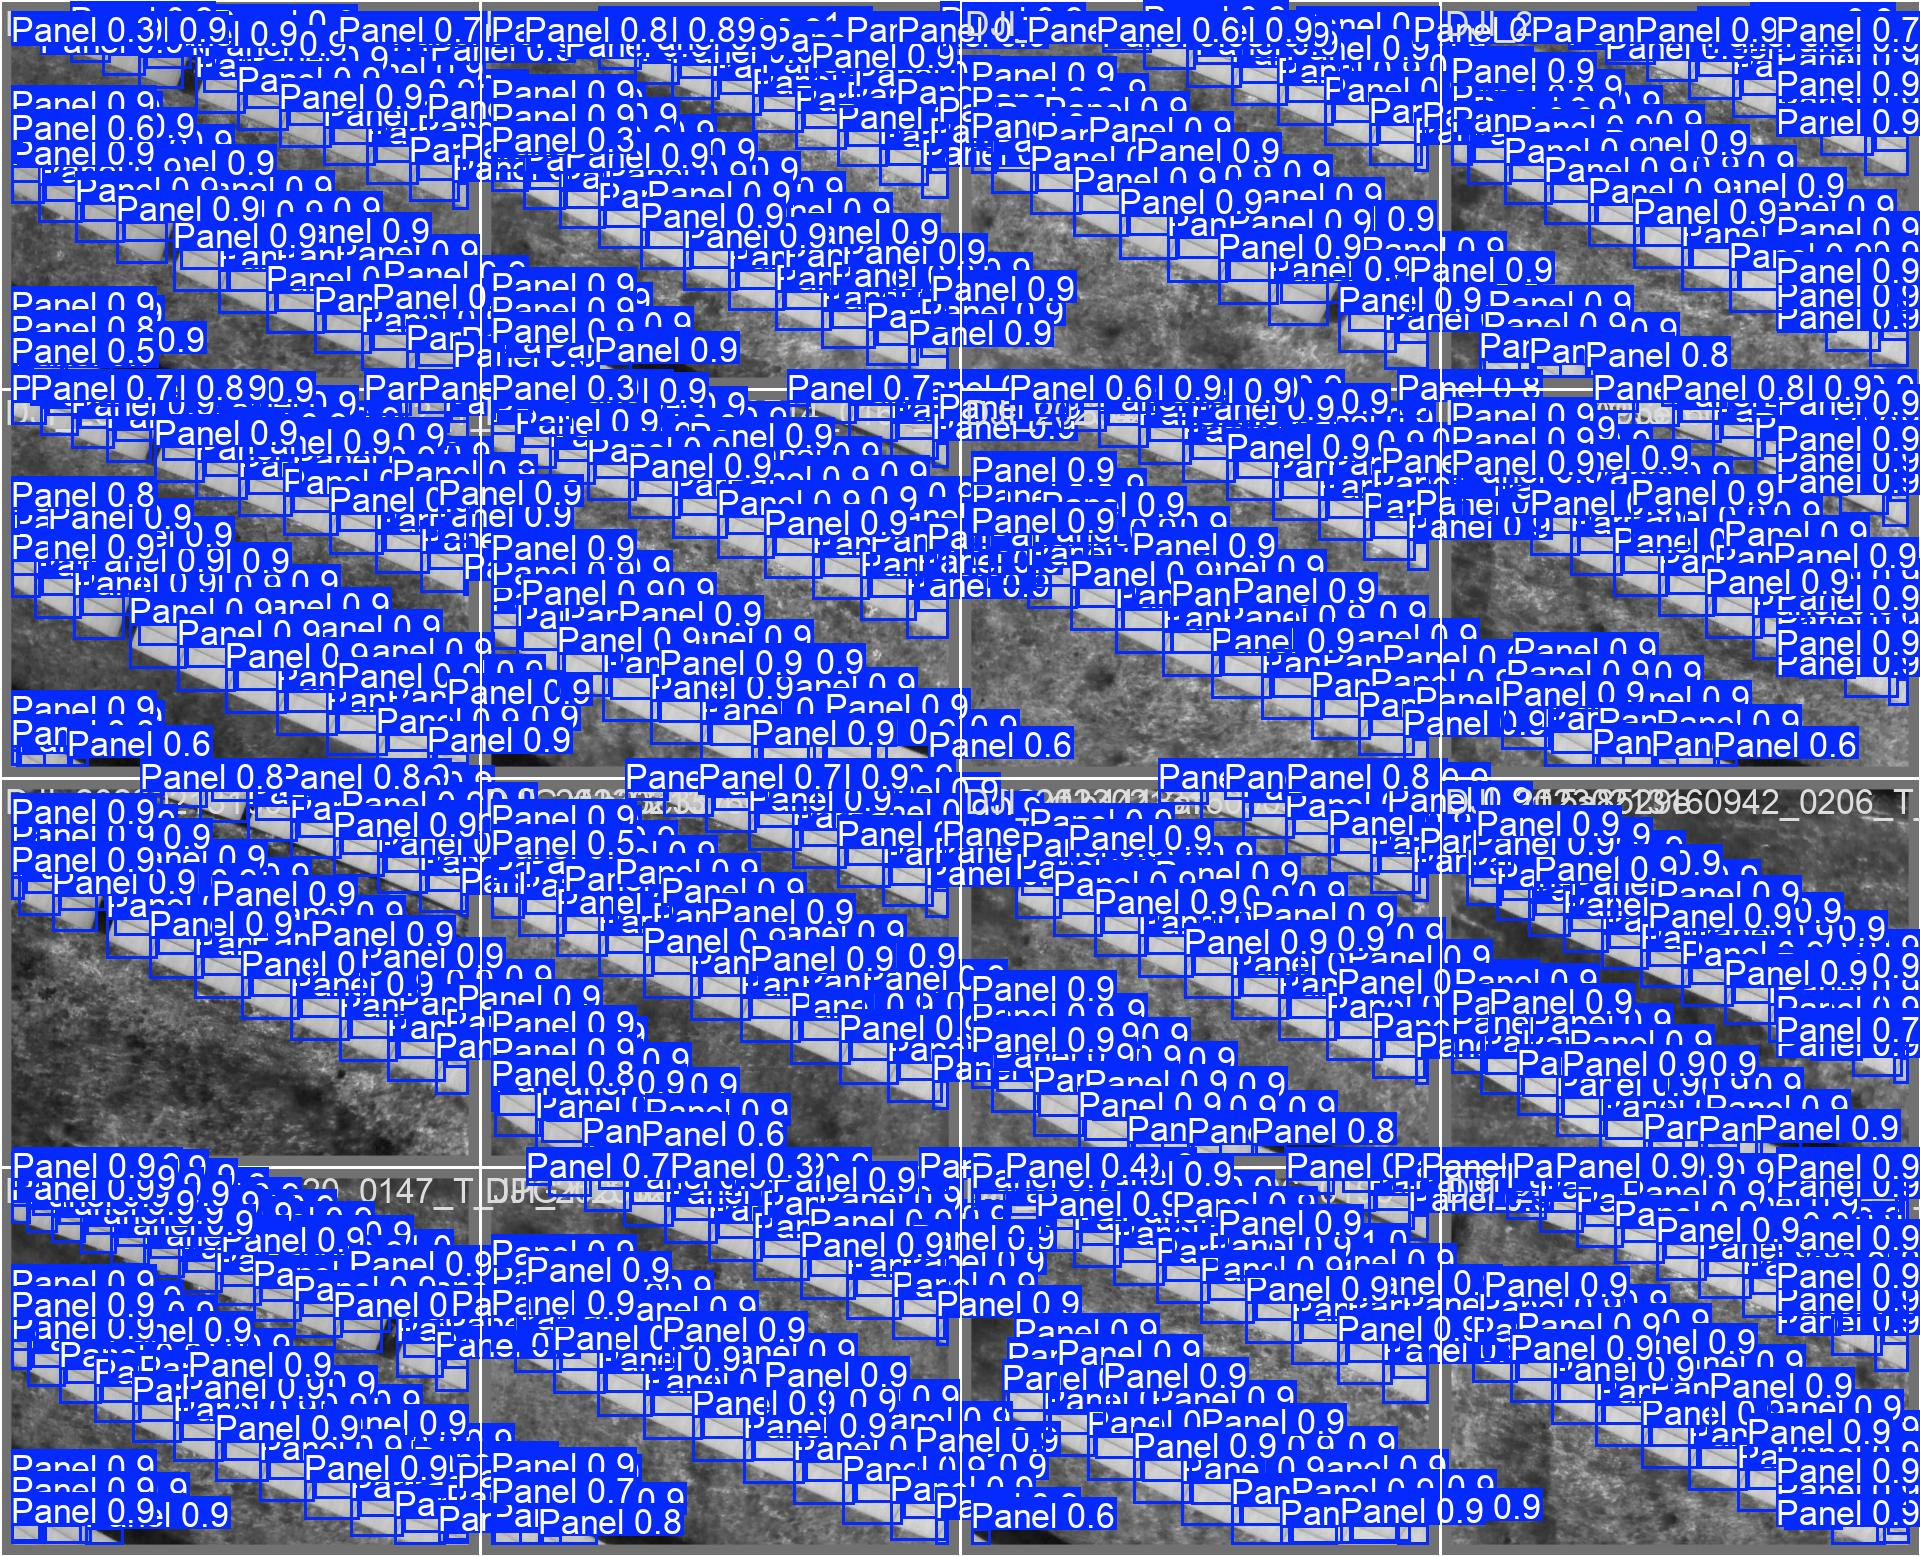

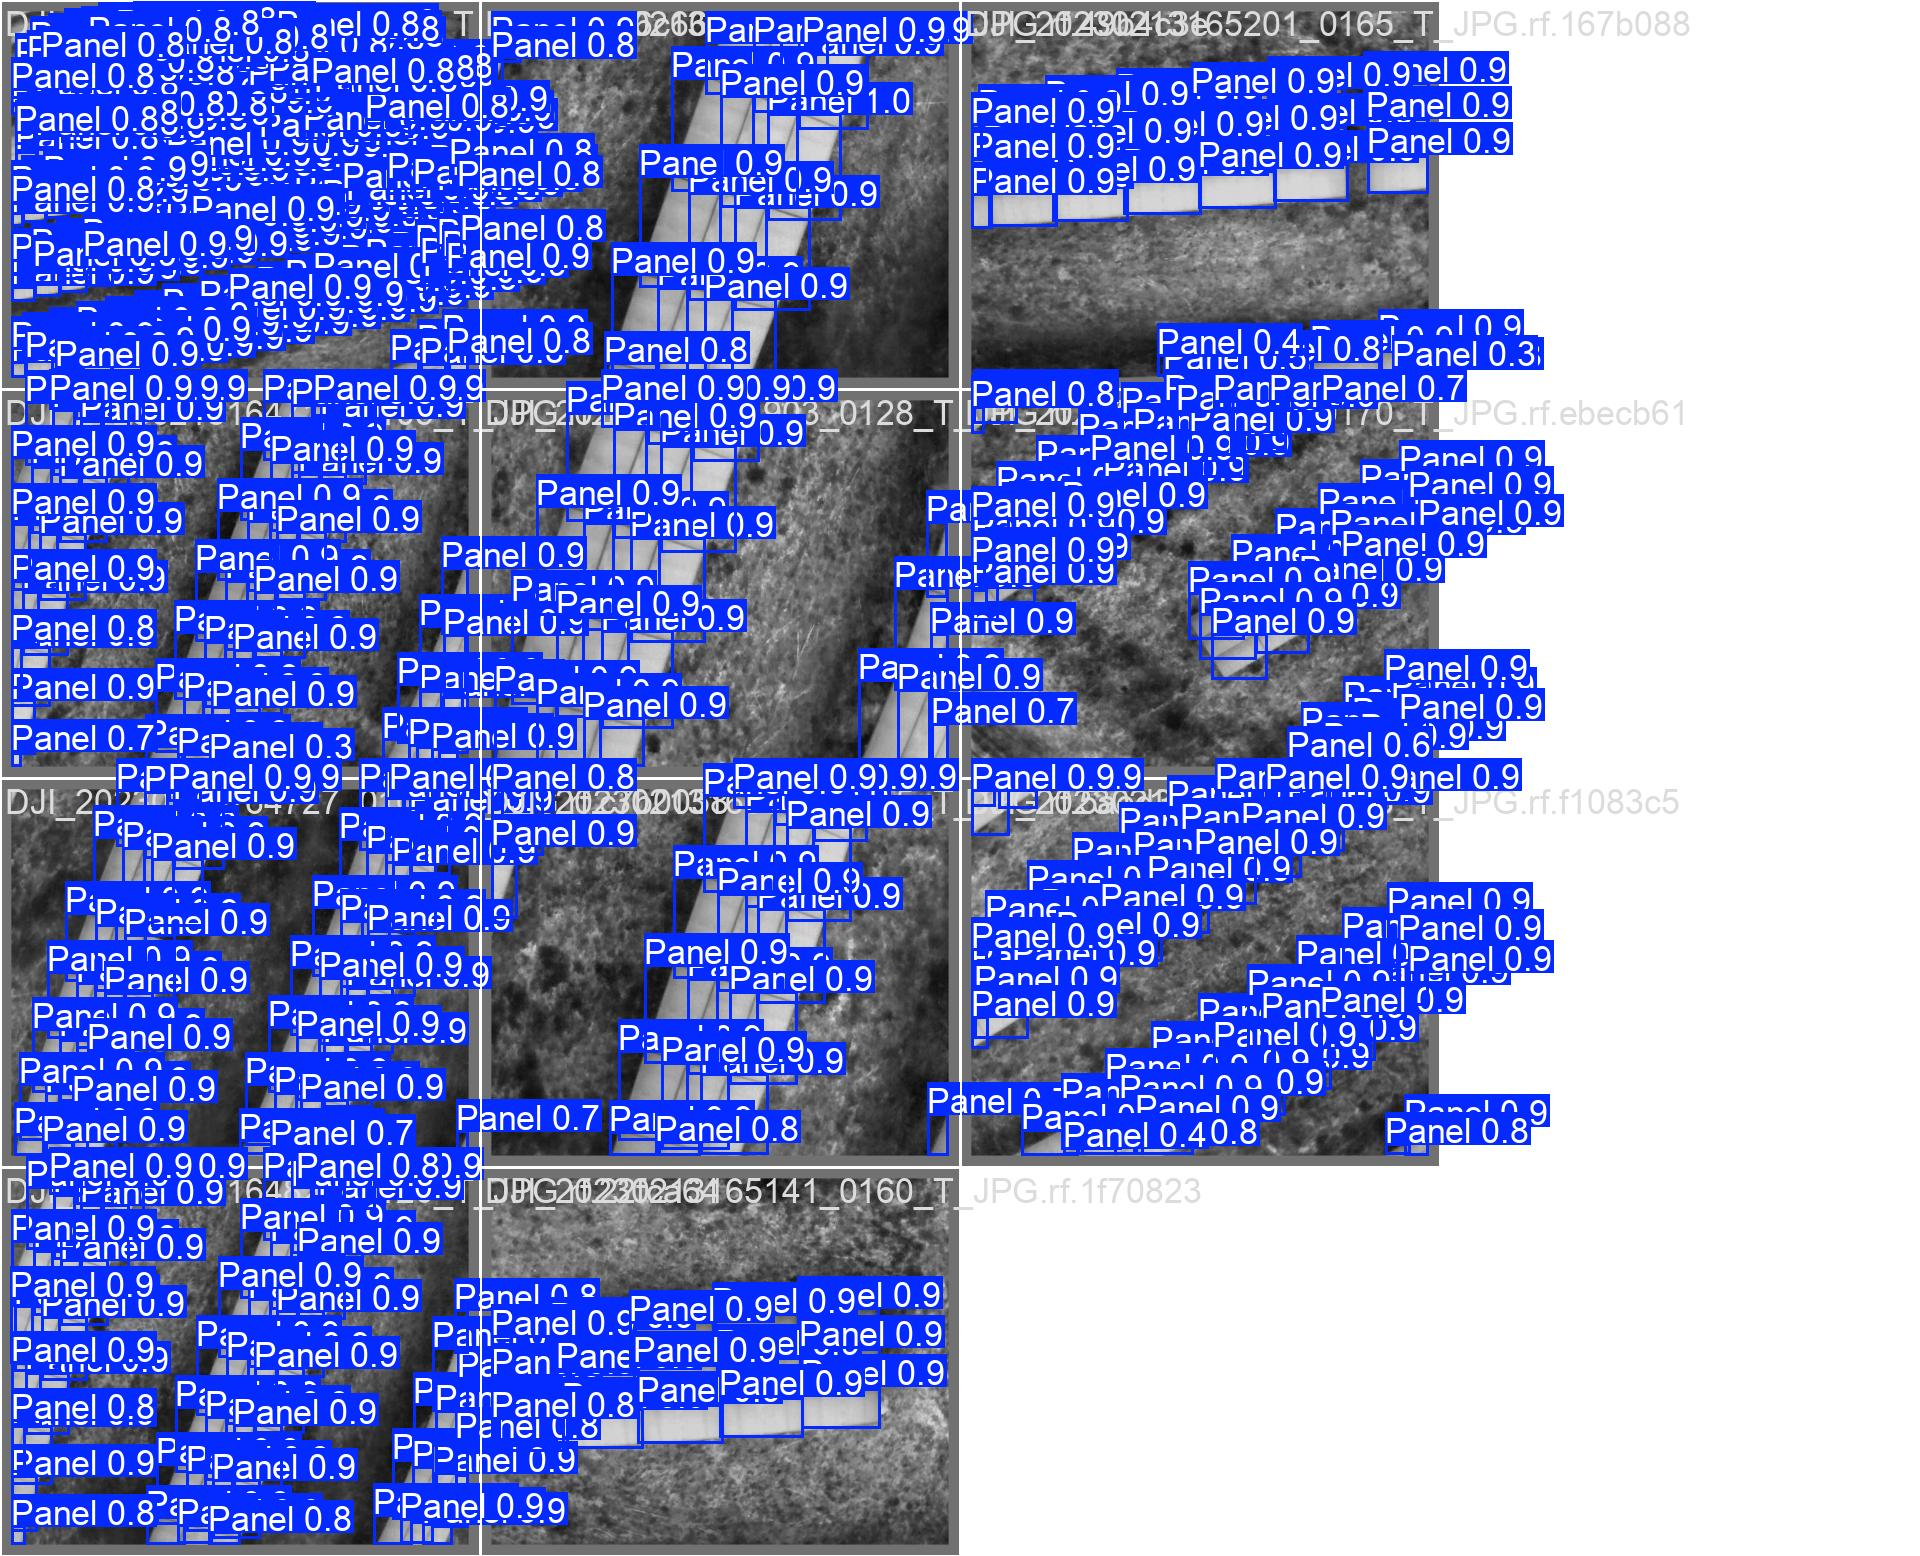

# Analyze the overlap between predicted and ground truth
Analyze the overlap between predicted and ground truth bounding boxes for the validation dataset, counting the number of predicted objects with an IOU of at least 50% with any ground truth object.

## Define label and image directories

### Subtask:
Specify the directories containing the predicted labels and the ground truth validation labels.


**Reasoning**:
Define the directories for predicted labels, ground truth labels, and validation images, and print them.



In [ ]:
import os

# Define the directory containing the predicted labels
predicted_labels_dir = '/content/yolov8_inference_output/predict/labels'

# Define the directory containing the ground truth validation labels
ground_truth_labels_dir = '/content/yolov8_dataset/val/labels'

# Define the directory containing the validation images
yolov8_dataset_dir = '/content/yolov8_dataset'
val_image_dir = os.path.join(yolov8_dataset_dir, 'val', 'images')


# Print the paths of the directories
print(f"Predicted labels directory: {predicted_labels_dir}")
print(f"Ground truth labels directory: {ground_truth_labels_dir}")
print(f"Validation image directory: {val_image_dir}")

Predicted labels directory: /content/yolov8_inference_output/predict/labels
Ground truth labels directory: /content/yolov8_dataset/val/labels
Validation image directory: /content/yolov8_dataset/val/images


**Reasoning**:
Calculate the IOU between predicted and ground truth bounding boxes for each image and count the number of predicted objects with an IOU of at least 50% with any ground truth object.



In [ ]:
import glob
import numpy as np

# Function to calculate IoU of two bounding boxes [x_center, y_center, width, height]
def calculate_iou(box1, box2):
    # Convert to [x_min, y_min, x_max, y_max]
    box1_xmin = box1[0] - box1[2] / 2
    box1_ymin = box1[1] - box1[3] / 2
    box1_xmax = box1[0] + box1[2] / 2
    box1_ymax = box1[1] + box1[3] / 2

    box2_xmin = box2[0] - box2[2] / 2
    box2_ymin = box2[1] - box2[3] / 2
    box2_xmax = box2[0] + box2[2] / 2
    box2_ymax = box2[1] + box2[3] / 2

    # Get the coordinates of the intersection rectangle
    inter_xmin = max(box1_xmin, box2_xmin)
    inter_ymin = max(box1_ymin, box2_ymin)
    inter_xmax = min(box1_xmax, box2_xmax)
    inter_ymax = min(box1_ymax, box2_ymax)

    # Calculate intersection area
    inter_width = max(0, inter_xmax - inter_xmin)
    inter_height = max(0, inter_ymax - inter_ymin)
    intersection_area = inter_width * inter_height

    # Calculate union area
    box1_area = (box1_xmax - box1_xmin) * (box1_ymax - box1_ymin)
    box2_area = (box2_xmax - box2_ymin) * (box2_ymax - box2_ymin)
    union_area = box1_area + box2_area - intersection_area

    # Handle case where union area is zero
    if union_area == 0:
        return 0.0

    # Calculate IoU
    iou = intersection_area / union_area
    return iou

# Get list of ground truth label files
ground_truth_label_files = glob.glob(os.path.join(ground_truth_labels_dir, '*.txt'))

predicted_objects_with_iou_above_threshold = 0
iou_threshold = 0.5

# Iterate through each ground truth label file
for gt_filepath in ground_truth_label_files:
    gt_filename = os.path.basename(gt_filepath)
    predicted_filepath = os.path.join(predicted_labels_dir, gt_filename)

    gt_boxes = []
    predicted_boxes = []

    # Read ground truth boxes
    try:
        with open(gt_filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    # Assuming format is class_id center_x center_y width height (normalized)
                    gt_boxes.append([float(p) for p in parts[1:]])
    except FileNotFoundError:
        print(f"Warning: Ground truth file not found for {gt_filename}")
        continue

    # Read predicted boxes
    try:
        with open(predicted_filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    # Assuming format is class_id center_x center_y width height confidence (normalized)
                    predicted_boxes.append([float(p) for p in parts[1:5]])
    except FileNotFoundError:
        # This image might not have any predictions
        continue

    # Compare predicted boxes with ground truth boxes
    for p_box in predicted_boxes:
        found_match = False
        for gt_box in gt_boxes:
            iou = calculate_iou(p_box, gt_box)
            if iou >= iou_threshold:
                predicted_objects_with_iou_above_threshold += 1
                found_match = True
                break # Move to the next predicted box once a match is found


print(f"Number of predicted objects with IoU >= {iou_threshold} with any ground truth object: {predicted_objects_with_iou_above_threshold}")

Number of predicted objects with IoU >= 0.5 with any ground truth object: 1264


## Summarize results

### Subtask:
Report the total number of predicted objects with >= 50% IOU overlap and potentially compare it to the total number of ground truth objects.


**Reasoning**:
Access the required variables and print the total counts and their difference as instructed.



In [ ]:
# Access the total number of predicted objects with an IoU of at least 50%
predicted_objects_iou_50 = predicted_objects_with_iou_above_threshold

# Access the total number of ground truth objects
total_ground_truth = total_ground_truth_objects

# Print the total number of predicted objects with >= 50% IOU overlap
print(f"Total number of predicted objects with >= 50% IOU overlap: {predicted_objects_iou_50}")

# Print the total number of ground truth objects
print(f"Total number of ground truth objects: {total_ground_truth}")

# Calculate and print the difference
difference = total_ground_truth - predicted_objects_iou_50
print(f"Difference (Ground Truth - Predicted with >= 50% IOU): {difference}")

Total number of predicted objects with >= 50% IOU overlap: 1264
Total number of ground truth objects: 7330
Difference (Ground Truth - Predicted with >= 50% IOU): 6066


## Summary:

### Data Analysis Key Findings

*   The total number of predicted objects with an IoU of at least 50% with any ground truth object was 1264.
*   There was a total of 7330 ground truth objects in the validation dataset.
*   The difference between the total ground truth objects and the predicted objects with an IoU of at least 50% was 6066.

### Insights or Next Steps

*   The significant difference between the number of ground truth objects and predicted objects with a good IoU suggests that the model is missing a large number of objects or has poor localization accuracy for many predictions.
*   Investigate the predictions with low IoU or the ground truth objects that were not matched to understand the specific failure modes of the model.


In [ ]:
import glob
import numpy as np
import os

# Define the directory containing the predicted labels
predicted_labels_dir = '/content/yolov8_inference_output/predict/labels'

# Define the directory containing the ground truth validation labels
ground_truth_labels_dir = '/content/yolov8_dataset/val/labels'


# Function to calculate IoU of two bounding boxes [x_center, y_center, width, height]
def calculate_iou(box1, box2):
    # Convert to [x_min, y_min, x_max, y_max]
    box1_xmin = box1[0] - box1[2] / 2
    box1_ymin = box1[1] - box1[3] / 2
    box1_xmax = box1[0] + box1[2] / 2
    box1_ymax = box1[1] + box1[3] / 2

    box2_xmin = box2[0] - box2[2] / 2
    box2_ymin = box2[1] - box2[3] / 2
    box2_xmax = box2[0] + box2[2] / 2
    box2_ymax = box2[1] + box2[3] / 2

    # Get the coordinates of the intersection rectangle
    inter_xmin = max(box1_xmin, box2_xmin)
    inter_ymin = max(box1_ymin, box2_ymin)
    inter_xmax = min(box1_xmax, box2_xmax)
    inter_ymax = min(box1_ymax, box2_ymax)

    # Calculate intersection area
    inter_width = max(0, inter_xmax - inter_xmin)
    inter_height = max(0, inter_ymax - inter_ymin)
    intersection_area = inter_width * inter_height

    # Calculate union area
    box1_area = (box1_xmax - box1_xmin) * (box1_ymax - box1_ymin)
    box2_area = (box2_xmax - box2_ymin) * (box2_ymax - box2_ymin)
    union_area = box1_area + box2_area - intersection_area

    # Handle case where union area is zero
    if union_area == 0:
        return 0.0

    # Calculate IoU
    iou = intersection_area / union_area
    return iou

# Get list of ground truth label files
ground_truth_label_files = glob.glob(os.path.join(ground_truth_labels_dir, '*.txt'))

predicted_objects_with_iou_above_threshold = 0
iou_threshold = 0.5

# Iterate through each ground truth label file
for gt_filepath in ground_truth_label_files:
    gt_filename = os.path.basename(gt_filepath)
    predicted_filepath = os.path.join(predicted_labels_dir, gt_filename)

    gt_boxes = []
    predicted_boxes = []

    # Read ground truth boxes
    try:
        with open(gt_filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    # Assuming format is class_id center_x center_y width height (normalized)
                    gt_boxes.append([float(p) for p in parts[1:]])
    except FileNotFoundError:
        print(f"Warning: Ground truth file not found for {gt_filename}")
        continue

    # Read predicted boxes
    try:
        with open(predicted_filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    # Assuming format is class_id center_x center_y width height confidence (normalized)
                    predicted_boxes.append([float(p) for p in parts[1:5]])
    except FileNotFoundError:
        # This image might not have any predictions
        continue

    # Compare predicted boxes with ground truth boxes
    for p_box in predicted_boxes:
        found_match = False
        for gt_box in gt_boxes:
            iou = calculate_iou(p_box, gt_box)
            if iou >= iou_threshold:
                predicted_objects_with_iou_above_threshold += 1
                found_match = True
                break # Move to the next predicted box once a match is found


print(f"Number of predicted objects with IoU >= {iou_threshold} with any ground truth object: {predicted_objects_with_iou_above_threshold}")

Number of predicted objects with IoU >= 0.5 with any ground truth object: 1264


In [ ]:
# Access the total number of predicted objects with an IoU of at least 50%
predicted_objects_iou_50 = predicted_objects_with_iou_above_threshold

# Access the total number of ground truth objects
total_ground_truth = total_ground_truth_objects

# Print the total number of predicted objects with >= 50% IOU overlap
print(f"Total number of predicted objects with >= 50% IOU overlap: {predicted_objects_iou_50}")

# Print the total number of ground truth objects
print(f"Total number of ground truth objects: {total_ground_truth}")

# Calculate and print the difference
difference = total_ground_truth - predicted_objects_iou_50
print(f"Difference (Ground Truth - Predicted with >= 50% IOU): {difference}")

Total number of predicted objects with >= 50% IOU overlap: 1264
Total number of ground truth objects: 7330
Difference (Ground Truth - Predicted with >= 50% IOU): 6066
